# TQD2026 notebook 1: *MPS time-evolution*
## The $t$-MPS method
 
This notebook defines example systems, runs time evolution, and plots the results. All implementation details are contained in `MPS_MPO_helpers.jl` module; 

What is covered in this notebook:

1. Define a Hamiltonian using the `OpSum` construction, commonly used in many algorithms like DMRG and TDVP.
2. Convert supported onsite and nearest-neighbour terms into a second-order odd/even/odd Trotter circuit.
3. Compile the circuit into one MPO for a single time step.
4. Apply the MPO repeatedly to an MPS using ITensor's default density-matrix MPO x MPS algorithm.
5. Track half-chain entanglement entropy to see the emergence of the MPS entanglement barrier.

In [1]:
using ITensors
using ITensorMPS
using Plots
using Printf
using LinearAlgebra

include("MPS_MPO_helpers.jl")
using .MPS_MPO_helpers

default(; linewidth=2, grid=false, framestyle=:box)

## Neel state quench with Heisenberg Hamiltonian

Begin by creating a function for constructing the `OpSum` of the antiferromagnetic Heisenberg chain:

In [2]:
function heisenberg_opsum(N; J=1.0)
  os = OpSum()
  for j in 1:(N - 1)
    os += J, "Sz", j, "Sz", j + 1
    os += 0.5J, "S+", j, "S-", j + 1
    os += 0.5J, "S-", j, "S+", j + 1
  end
  return os
end;

Given the Hamiltonian defined as an `OpSum` we now create a second-order Trotter circuit for it (as shown before for a nearest-neighbour Hamiltonian) and then we compile this into a single time-step MPO:

<center>
<img src="images/trotter_circuit.png" width="400">
</center>

Here we perform a check that the compiled-MPO (so t-MPS approach) gives the same result as applying the raw two-site gate circuit directly (a TEBD style approach).

In [3]:
N_check = 10
dt_check = 0.05
sites_check = siteinds("S=1/2", N_check)

H_check = heisenberg_opsum(N_check; J=1.0)
layers_check = second_order_trotter_circuit(H_check, sites_check, dt_check)
Udt_check = circuit_mpo(layers_check, sites_check; cutoff=1e-14)

layer_summary = [(layer.name, layer.time_fraction, layer.blocks) for layer in layers_check]
@show layer_summary
@show maxlinkdim(Udt_check);

layer_summary = Tuple{Symbol, Float64, Vector{UnitRange{Int64}}}[(:layer_1, 0.5, [1:2, 3:4, 5:6, 7:8, 9:10]), (:layer_2, 1.0, [2:3, 4:5, 6:7, 8:9]), (:layer_3, 0.5, [1:2, 3:4, 5:6, 7:8, 9:10])]
maxlinkdim(Udt_check) = 9


In [4]:
psi0_check = MPS(ComplexF64, sites_check, n -> isodd(n) ? "Up" : "Dn")

psi_gate = apply(flatten_gates(layers_check), psi0_check; cutoff=1e-13)
normalize!(psi_gate)
@show maxlinkdim(psi_gate);

psi_mpo = apply_mpo_step(Udt_check, psi0_check; cutoff=1e-13, maxdim=1000)
@show maxlinkdim(psi_mpo);

one_step_error = abs(1 - abs(inner(psi_gate, psi_mpo)))
println(@sprintf("|1 - |<psi_gate|psi_mpo>|| = %.3e", one_step_error))

maxlinkdim(psi_gate) = 4
maxlinkdim(psi_mpo) = 4
|1 - |<psi_gate|psi_mpo>|| = 1.787e-14


This establishes that the method works as advertised.

## Entanglement Barrier after a quench

We now quench the Neel product state under the antiferromagnetic Heisenberg Hamiltonian. Entanglement spreads from the initial product state, so the half-chain entropy grows. An MPS with maximum bond dimension `chi` cannot represent more than about `log(chi)` entropy across a bond, so low-`maxdim` simulations hit an entanglement barrier very quickly.

Start by setting up the parameters of the problem:

In [5]:
N_heis = 18
dt_heis = 0.05
total_time_heis = 5.0
nsteps_heis = round(Int, total_time_heis / dt_heis)
cutoff_heis = 1e-8
maxdims_heis = [4, 8, 16, 32]
entropy_bond_heis::Integer = div(N_heis, 2)
sz_site_heis::Integer = div(N_heis, 2);

Construct Hamiltonian, evolution MPO and the Neel initial state:

In [6]:
sites_heis = siteinds("S=1/2", N_heis)
H_heis = heisenberg_opsum(N_heis; J=1.0)
layers_heis = second_order_trotter_circuit(H_heis, sites_heis, dt_heis)
Udt_heis = circuit_mpo(layers_heis, sites_heis; cutoff=1e-13)
psi0_heis = MPS(ComplexF64, sites_heis, n -> isodd(n) ? "Up" : "Dn");

Repeatedly run the time evolution with a sequence of increasing bond dimensions:

In [7]:
runs = Dict{Int,Any}()

for maxdim in maxdims_heis
  println("Running maxdim = $maxdim")

  runs[maxdim] = (
    times = Float64[],
    entropies = Float64[],
    maxlinkdims = Int[],
    sz_values = Float64[],
  )

  psi_heis = copy(psi0_heis)

  for step in 0:nsteps_heis
    push!(runs[maxdim].times, step * dt_heis)
    push!(runs[maxdim].entropies, half_chain_entropy(psi_heis; bond=entropy_bond_heis))
    push!(runs[maxdim].maxlinkdims, maxlinkdim(psi_heis))
    push!(runs[maxdim].sz_values, real(expect(psi_heis, "Sz"; sites=sz_site_heis)))

    step == nsteps_heis && break
    psi_heis = apply_mpo_step(Udt_heis, psi_heis; cutoff=cutoff_heis, maxdim=maxdim)
  end
end

[(maxdim, runs[maxdim].entropies[end], maximum(runs[maxdim].maxlinkdims)) for maxdim in maxdims_heis]

Running maxdim = 4
Running maxdim = 8
Running maxdim = 16
Running maxdim = 32


4-element Vector{Tuple{Int64, Float64, Int64}}:
 (4, 1.2503431298380454, 4)
 (8, 1.9171919043784196, 8)
 (16, 2.390412206813072, 16)
 (32, 2.5258705919582924, 32)

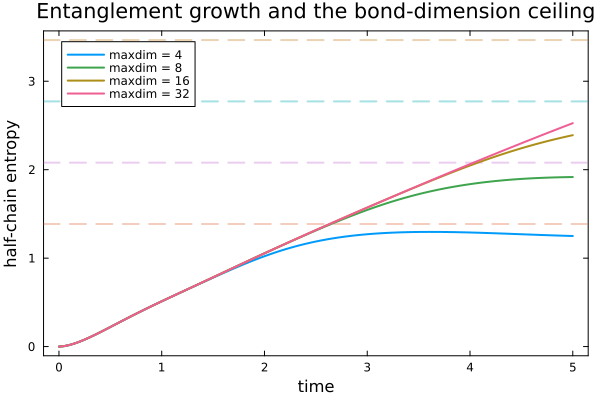

In [8]:
p_heis_entropy = plot(
  xlabel="time",
  ylabel="half-chain entropy",
  title="Entanglement growth and the bond-dimension ceiling",
  legend=:topleft,
)

for maxdim in maxdims_heis
  data = runs[maxdim]
  plot!(p_heis_entropy, data.times, data.entropies; label="maxdim = $maxdim")
  hline!(p_heis_entropy, [log(maxdim)]; linestyle=:dash, alpha=0.35, label="")
end

p_heis_entropy

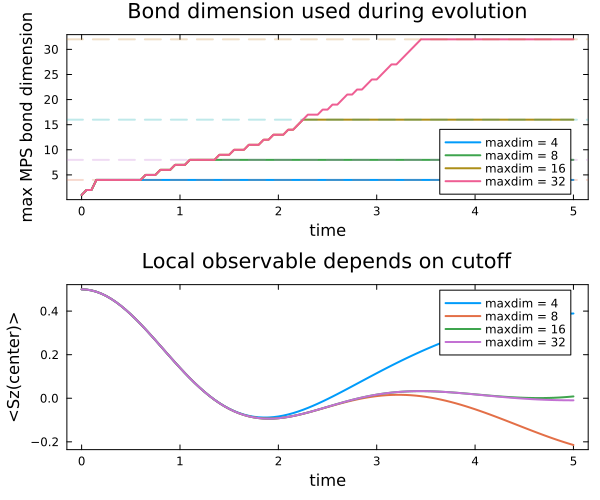

In [9]:
p_heis_bonds = plot(
  xlabel="time",
  ylabel="max MPS bond dimension",
  title="Bond dimension used during evolution",
  legend=:bottomright,
)

p_heis_sz = plot(
  xlabel="time",
  ylabel="<Sz(center)>",
  title="Local observable depends on cutoff",
  legend=:topright,
)

for maxdim in maxdims_heis
  data = runs[maxdim]
  plot!(p_heis_bonds, data.times, data.maxlinkdims; label="maxdim = $maxdim")
  hline!(p_heis_bonds, [maxdim]; linestyle=:dash, alpha=0.25, label="")
  plot!(p_heis_sz, data.times, data.sz_values; label="maxdim = $maxdim")
end

plot(p_heis_bonds, p_heis_sz; layout=(2, 1), size=(600, 500))

## Tilted-Ising model quench

This example of a quench of a ferromagnetic state with a tilted-field Ising Hamiltonian demonstrating a mix of two-site and on-site terms.

In [10]:
function tilted_field_ising_opsum(N; J=1.0, hx=1.05, hz=0.5)
  os = OpSum()
  for j in 1:(N - 1)
    os += -4J, "Sz", j, "Sz", j + 1
  end
  for j in 1:N
    os += -2hx, "Sx", j
    os += -2hz, "Sz", j
  end
  return os
end;

Pick some parameters which are small enough for comparison to exact diagonalization:

In [11]:
N_ising = 8
dt_ising = 0.05
total_time_ising = 5.0
nsteps_ising = round(Int, total_time_ising / dt_ising)
cutoff_ising = 1e-15
maxdim_ising = 8
entropy_bond_ising::Integer = div(N_ising, 2)
sz_site_ising::Integer = div(N_ising, 2);

Define MPS components:

In [12]:
sites_ising = siteinds("S=1/2", N_ising)
H_ising = tilted_field_ising_opsum(N_ising; J=1.0, hx=1.05, hz=0.5)
layers_ising = second_order_trotter_circuit(H_ising, sites_ising, dt_ising)
Udt_ising = circuit_mpo(layers_ising, sites_ising; cutoff=1e-13)
psi_ising0 = MPS(ComplexF64, sites_ising, "Up");

Run the t-MPS calculation:

In [13]:
ising = (
  times = Float64[],
  entropies = Float64[],
  maxlinkdims = Int[],
  sz_values = Float64[],
)
  
psi_ising = copy(psi_ising0)
for step in 0:nsteps_ising
  push!(ising.times, step * dt_ising)
  push!(ising.entropies, half_chain_entropy(psi_ising; bond=entropy_bond_ising))
  push!(ising.maxlinkdims, maxlinkdim(psi_ising))
  push!(ising.sz_values, real(expect(psi_ising, "Sz"; sites=sz_site_ising)))

  step == nsteps_ising && break
  psi_ising = apply_mpo_step(Udt_ising, psi_ising; cutoff=cutoff_ising, maxdim=maxdim_ising)
end

Now setup the parts needed for an exact diagonalization version of this Trotterized evolution:

In [14]:
H_ising_matrix = dense_operator_matrix(H_ising, sites_ising) #Full Hamiltonian matrix of the problem

println(@sprintf("dense Hilbert-space dimension = %d", size(H_ising_matrix, 1)))

eig_ising = eigen(Hermitian(H_ising_matrix))
U_ising_exact = eig_ising.vectors * Diagonal(exp.(-im * dt_ising .* eig_ising.values)) * eig_ising.vectors' #Exact Trotter step propagator

Sz_center_ops = OpSum()
Sz_center_ops += "Sz", sz_site_ising
Sz_center_matrix = dense_operator_matrix(Sz_center_ops, sites_ising) #Observable we want to evaluate

psi_ising_exact = dense_state_vector(psi_ising0, sites_ising);

dense Hilbert-space dimension = 256


Now run the exact Trotter steps:

In [15]:
exact_ising = (
    times = Float64[],
    entropies = Float64[],
    sz_values = Float64[],
  )

for step in 0:nsteps_ising
  push!(exact_ising.times, step * dt_ising)
  push!(exact_ising.entropies, dense_half_chain_entropy(psi_ising_exact, sites_ising; bond=entropy_bond_ising))
  push!(exact_ising.sz_values, real(dot(psi_ising_exact, Sz_center_matrix * psi_ising_exact)))

  step == nsteps_ising && break
  psi_ising_exact = U_ising_exact * psi_ising_exact
end

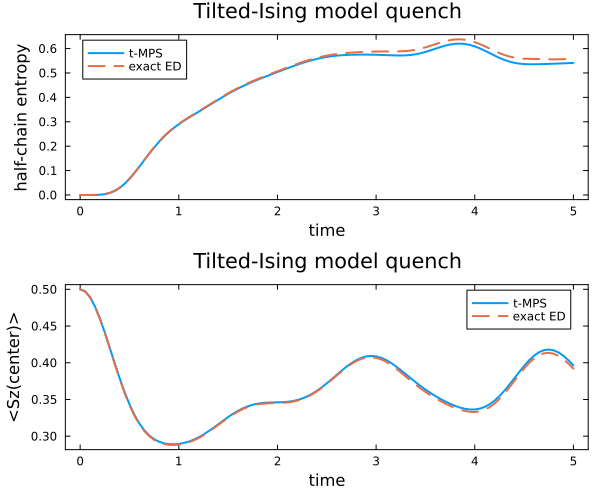

In [16]:
p_ising_entropy = plot(
  ising.times,
  ising.entropies;
  xlabel="time",
  ylabel="half-chain entropy",
  label="t-MPS",
  title="Tilted-Ising model quench",
)
plot!(p_ising_entropy, exact_ising.times, exact_ising.entropies; linestyle=:dash, label="exact ED")

p_ising_sz = plot(
  ising.times,
  ising.sz_values;
  xlabel="time",
  ylabel="<Sz(center)>",
  label="t-MPS",
  title="Tilted-Ising model quench",
  legend=:topright,
)
plot!(p_ising_sz, exact_ising.times, exact_ising.sz_values; linestyle=:dash, label="exact ED")

plot(p_ising_entropy, p_ising_sz; layout=(2, 1), size=(600, 500))

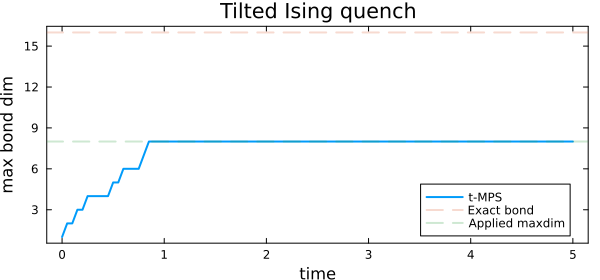

In [17]:
p_ising_bond = plot(
  ising.times,
  ising.maxlinkdims;
  xlabel="time",
  ylabel="max bond dim",
  label="t-MPS",
  title="Tilted Ising quench",
)
hline!(p_ising_bond, [sqrt(size(H_ising_matrix, 1))]; linestyle=:dash, alpha=0.25, label="Exact bond")
hline!(p_ising_bond, [maxdim_ising]; linestyle=:dash, alpha=0.25, label="Applied maxdim")

plot(p_ising_bond; size=(600, 280))

Neither calculation is formally "exact" since both are Trotterized, but t-MPS delibrately differs from the exact Trotter evolution since bond dimension required to track the full state exceeds the `maxdim` set at the start. 